In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('./data/voice.csv') 

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
df.info()
df.describe()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

label
male      1584
female    1584
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(cols, k=5):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    return cross_val_score(model, X_train[cols], y_train, cv=cv).mean()

print('akurasi cv knn:', round(cv_score(list(X.columns)), 4))

d:\Download\anaconda\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Download\anaconda\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\Download\anaconda\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Download\anaconda\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~

akurasi cv knn: 0.9696


In [4]:
selected = []
remaining = list(X.columns)
history = []

while remaining:
    scores = {f: cv_score(selected+[f]) for f in remaining}
    best_f = max(scores, key=scores.get)
    selected.append(best_f)
    remaining.remove(best_f)
    history.append((len(selected), best_f, scores[best_f]))

hist = pd.DataFrame(history, columns=['n_fitur', 'fitur_ditambah', 'akurasi_cv'])
print(hist)

    n_fitur fitur_ditambah  akurasi_cv
0         1        meanfun    0.940803
1         2            IQR    0.968034
2         3            sfm    0.976717
3         4           mode    0.980663
4         5           skew    0.981057
5         6           kurt    0.981057
6         7         minfun    0.979871
7         8         sp.ent    0.980267
8         9         maxdom    0.980659
9        10             sd    0.980660
10       11         median    0.981052
11       12         maxfun    0.978685
12       13            Q25    0.977107
13       14       meanfreq    0.977108
14       15       centroid    0.977502
15       16            Q75    0.974739
16       17        dfrange    0.973557
17       18        modindx    0.972768
18       19        meandom    0.970792
19       20         mindom    0.969609


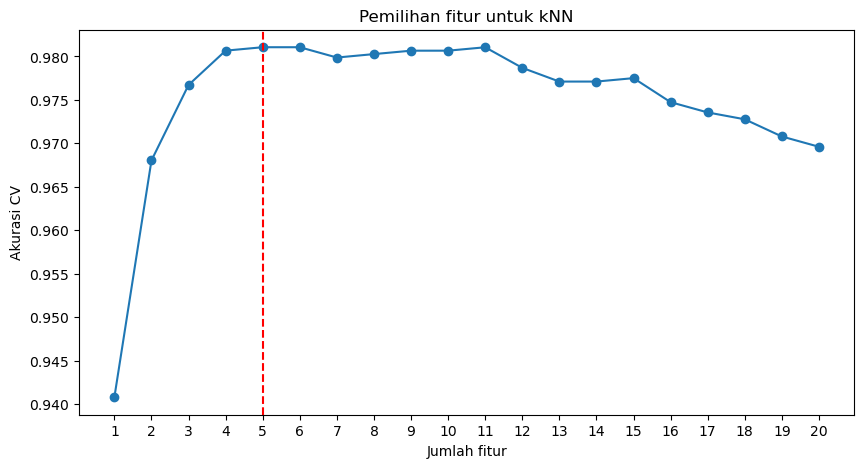

Fitur terpilih: ['meanfun', 'IQR', 'sfm', 'mode', 'skew']


In [5]:
plt.figure(figsize=(10, 5))
plt.plot(hist['n_fitur'], hist['akurasi_cv'], marker='o')
best_row = hist.loc[hist['akurasi_cv'].idxmax()]
plt.axvline(best_row['n_fitur'], color='red', linestyle='--',label=f"Terbaik: {int(best_row['n_fitur'])} fitur ({best_row['akurasi_cv']:.4f})")
plt.xticks(hist['n_fitur'])
plt.xlabel('Jumlah fitur')
plt.ylabel('Akurasi CV')
plt.title('Pemilihan fitur untuk kNN')
plt.show()

best_n = int(best_row['n_fitur'])
fitur = hist['fitur_ditambah'].iloc[:best_n].tolist()
print("Fitur terpilih:", fitur)

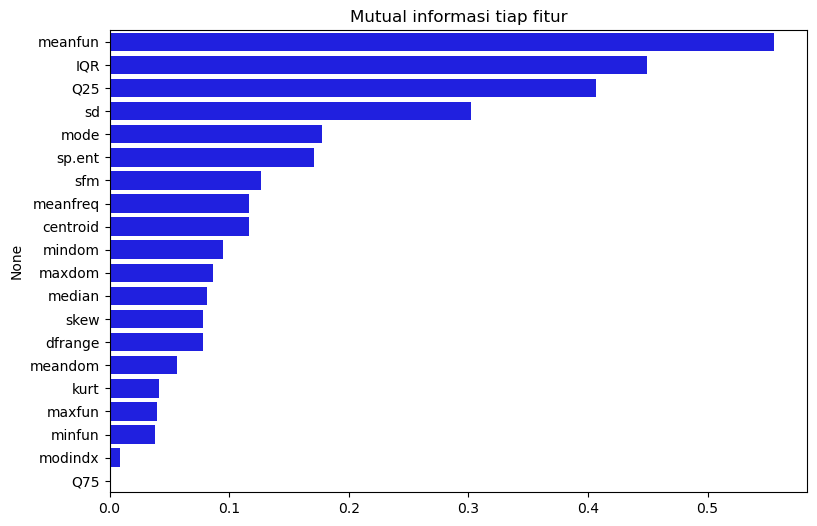

1 fitur teratas: 0.9408
2 fitur teratas: 0.968
3 fitur teratas: 0.9736
4 fitur teratas: 0.9787
5 fitur teratas: 0.9771
6 fitur teratas: 0.9763
7 fitur teratas: 0.9771
8 fitur teratas: 0.9779
9 fitur teratas: 0.9791
10 fitur teratas: 0.9739


In [6]:
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns

mic = pd.Series(mutual_info_classif(X_train, y_train, random_state=42), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=mic.values, y=mic.index, color='blue')
plt.title('Mutual informasi tiap fitur')
plt.show()

for n in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    print(n, "fitur teratas:", round(cv_score(list(mic.index[:n])), 4))

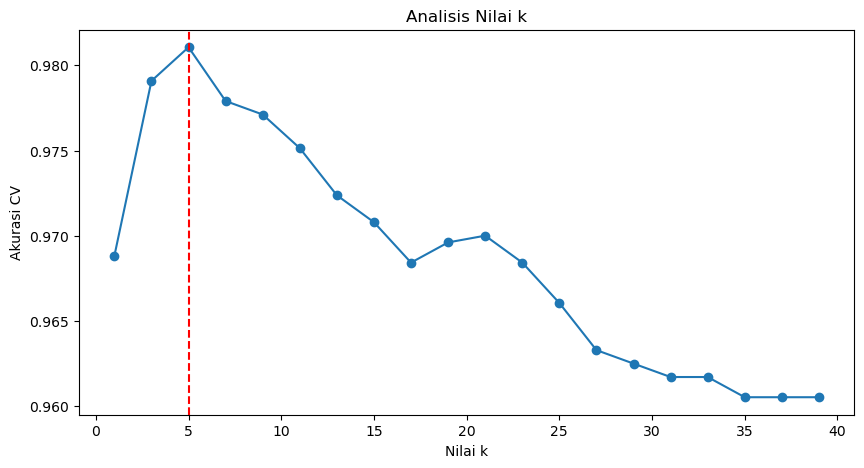

k terbaik: 5


In [7]:
k_range = range(1, 41, 2)
means, stds = [], []

for k in k_range:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    s = cross_val_score(model, X_train[fitur], y_train, cv=cv)
    means.append(s.mean()); stds.append(s.std())

means, stds = np.array(means), np.array(stds)
best_k = list(k_range)[means.argmax()]

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), means, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'k terbaik = {best_k} ({means.max():.4f})')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi CV')
plt.title('Analisis Nilai k')
plt.show()

print("k terbaik:", best_k)

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
final_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
final_model.fit(X_train[fitur], y_train)
y_pred = final_model.predict(X_test[fitur])

print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 0.9873817034700315
Confusion Matrix:
 [[312   5]
 [  3 314]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.99      0.98      0.99       317
        male       0.98      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634

